# **iitg.ai recruitment**

## Author -suveer shandilya

---
## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

print('ok')

ok


---
##  Load the data

In [19]:
df = pd.read_excel('/kaggle/input/datasets/suveerkaggle/dataset/PGCB_date_power_demand.xlsx')
df=df[['datetime','generation_mw','demand_mw']].copy()
df = df.sort_values('datetime').reset_index(drop=True)
df['demand_mw'] = df['demand_mw'].astype(float)
print(f'Rows: {len(df)}')
print(f'Date range: {df['datetime'].min()}  to  {df['datetime'].max()}')
df[['datetime','demand_mw']].head(6)
print(df.describe())

Rows: 92650
Date range: 2015-04-19 00:00:00  to  2025-06-17 12:00:00
                            datetime  generation_mw      demand_mw
count                          92650   9.265000e+04   92650.000000
mean   2020-05-17 03:52:07.609282304   9.429376e+03    8819.646044
min              2015-04-19 00:00:00   7.300000e+01       6.000000
25%              2017-10-31 06:15:00   6.814775e+03    6812.250000
50%              2020-05-21 15:30:00   8.412000e+03    8422.000000
75%              2022-12-03 18:22:30   1.055600e+04   10633.000000
max              2025-06-17 12:00:00   6.452650e+07  156050.000000
std                              NaN   2.119759e+05    2772.150108


---
## Clean data

Three problems to fix:
- Some timestamps are at **:30** — we want only :00 (one row per hour)
- Some **hours are completely missing**
- Some values are **impossible spikes** (e.g. 156,000 MW)

---

In [3]:
df = df.set_index('datetime')
df = df[~df.index.duplicated(keep='first')]
df = df.resample('1h').mean()
df['demand_mw'] = df['demand_mw'].ffill()

In [4]:
roll = df['demand_mw'].rolling(window=168, center=True, min_periods=24)
q1  = roll.quantile(0.25)
q3  = roll.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

is_spike = (df['demand_mw'] < lower) | (df['demand_mw'] > upper)
df.loc[is_spike, 'demand_mw'] = roll.median()[is_spike]

print(f"Max after step1: {df['demand_mw'].max():.0f} MW")
GLOBAL_CAP   = df['demand_mw'].quantile(0.999)  # upper limit
GLOBAL_FLOOR = df['demand_mw'].quantile(0.001)  # lower limit

print('Global cap   (99.9th percentile):', round(GLOBAL_CAP), 'MW')
print('Global floor  (0.1th percentile):', round(GLOBAL_FLOOR), 'MW')

# Clip everything to stay within these bounds
df['demand_mw'] = df['demand_mw'].clip(lower=GLOBAL_FLOOR, upper=GLOBAL_CAP)

print('\nFinal max demand:', df['demand_mw'].max(), 'MW')
print('Final min demand:', df['demand_mw'].min(), 'MW')

Max after step1: 17200 MW
Global cap   (99.9th percentile): 16200 MW
Global floor  (0.1th percentile): 3498 MW

Final max demand: 16200.0 MW
Final min demand: 3498.3 MW


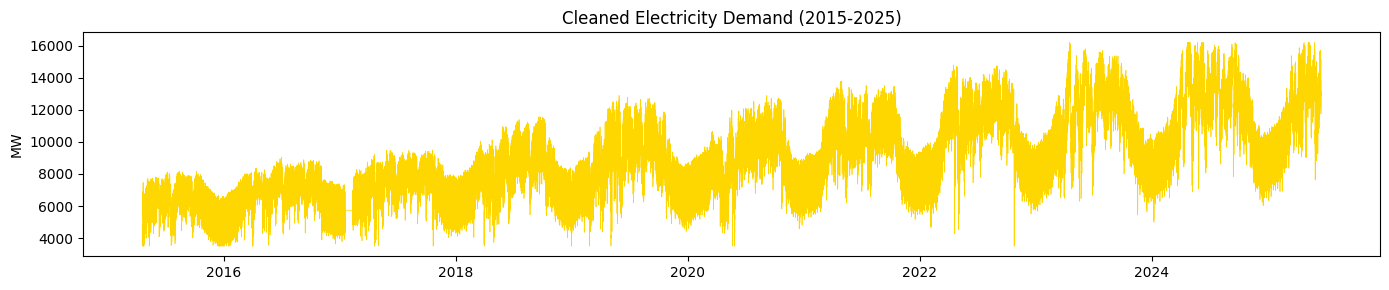

In [15]:
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(df.index, df['demand_mw'], lw=0.5, color='#FFD700')
ax.set_title('Cleaned Electricity Demand (2015-2025)')
ax.set_ylabel('MW')
plt.tight_layout()
plt.show()

---
## Add Weather Data

Hot weather -> more air conditioners -> higher electricity demand.  
Keeping it simple by taking only temprature.
Feature: temperature.

In [6]:

# skiprows=3 skips the 3 metadata rows at the top of the file
weather = pd.read_excel(
    '/kaggle/input/datasets/suveerkaggle/dataset/weather_data.xlsx',
    skiprows=3,
    header=0,
    usecols=[0, 1]   # only the first two columns: time and temperature
)

weather.columns = ['time', 'temp']

weather['time'] = pd.to_datetime(weather['time'])
weather['temp'] = pd.to_numeric(weather['temp'], errors='coerce')

weather = weather.sort_values('time').drop_duplicates(subset='time', keep='first')
weather = weather.set_index('time')

print('Weather rows:', len(weather))
print('Weather range:', weather.index.min(), 'to', weather.index.max())
weather.head(4)

Weather rows: 107304
Weather range: 2014-01-01 00:00:00 to 2026-03-29 23:00:00


,temp
time,
2014-01-01 00:00:00,13.9
2014-01-01 01:00:00,13.6
2014-01-01 02:00:00,13.3
2014-01-01 03:00:00,13.0


In [7]:

data = df.join(weather[['temp']], how='left')

print('Rows after joining weather:', len(data))
print('Missing temperature values:', data['temp'].isna().sum())
data[['demand_mw', 'temp']].head(4)

Rows after joining weather: 89101
Missing temperature values: 0


,demand_mw,temp
datetime,,
2015-04-19 00:00:00,4821.0,25.7
2015-04-19 01:00:00,3612.0,25.3
2015-04-19 02:00:00,3727.0,24.9
2015-04-19 03:00:00,3632.0,25.0


---
## Features


| Feature | What it tells the model |
|---|---|
| `hour`, `hour_sin/cos` | Time of day |
| `day_of_week`, `month` | Day and season |
| `lag_1h`, `lag_24h` | What demand was recently |
| `avg_last_6h`, `avg_last_24h` | Recent trend |
| `temp` | Temperature (hot = more ACs = more demand) |

In [8]:


#Calendar features 
data['hour']        = data.index.hour
data['day_of_week'] = data.index.dayofweek
data['month']       = data.index.month
data['is_weekend']  = (data['day_of_week'] >= 5).astype(int)

#Cyclical encoding
data['hour_sin']  = np.sin(2 * np.pi * data['hour']  / 24)
data['hour_cos']  = np.cos(2 * np.pi * data['hour']  / 24)
data['month_sin'] = np.sin(2 * np.pi * data['month'] / 12)
data['month_cos'] = np.cos(2 * np.pi * data['month'] / 12)

#Lag features
data['lag_1h']   = data['demand_mw'].shift(1)   
data['lag_2h']   = data['demand_mw'].shift(2) 
data['lag_3h']   = data['demand_mw'].shift(3)   
data['lag_24h']  = data['demand_mw'].shift(24)  
data['lag_168h'] = data['demand_mw'].shift(168)  

# Rolling average features
past = data['demand_mw'].shift(1)  
data['avg_last_6h']  = past.rolling(6).mean()
data['avg_last_24h'] = past.rolling(24).mean()
data['avg_last_7d']  = past.rolling(168).mean()

#Target
data['target'] = data['demand_mw'].shift(-1)
data = data.dropna()

print('Final dataset:', f'{len(data):,}', 'rows')

Final dataset: 87,908 rows


---
## Train / Test Split

Train on **2015 to 2023**, test on **2024** onwards.

In [9]:
FEATURES = [
    'hour', 'day_of_week', 'month', 'is_weekend',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'lag_1h', 'lag_2h', 'lag_3h', 'lag_24h', 'lag_168h',
    'avg_last_6h', 'avg_last_24h', 'avg_last_7d',
    'temp',
]

train = data[data.index.year <= 2023]
test  = data[data.index.year >= 2024]

X_train, y_train = train[FEATURES], train['target']
X_test,  y_test  = test[FEATURES],  test['target']

print('Train:', f'{len(X_train):,}', 'rows', '(', train.index.min().date(), 'to', train.index.max().date(), ')')
print('Test :', f'{len(X_test):,}', 'rows', '(', test.index.min().date(), 'to', test.index.max().date(), ')')

Train: 75,119 rows ( 2015-04-26 to 2023-12-31 )
Test : 12,789 rows ( 2024-01-01 to 2025-06-17 )


---
## Step 6 — Train the Model

In [10]:
model = RandomForestRegressor(
    n_estimators = 100,
    max_depth    = 15,
    random_state = 100,
    n_jobs       = -1
)

print('training')
model.fit(X_train, y_train)
print('finished')

Training...
Done!


---
## Step 7 — Evaluate

In [11]:
predictions = model.predict(X_test)

def mape(actual, predicted):
    actual    = np.array(actual)
    predicted = np.array(predicted)
    mask = actual != 0
    return 100 * np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask]))

score = mape(y_test, predictions)
mape   = mean_absolute_error(y_test, predictions)

print(f'  Test MAPE : {score:.3f}%')
print(f'  Test MAPE  : {mape:.0f} MW')

  Test MAPE : 2.927%
  Test MAPE  : 330 MW


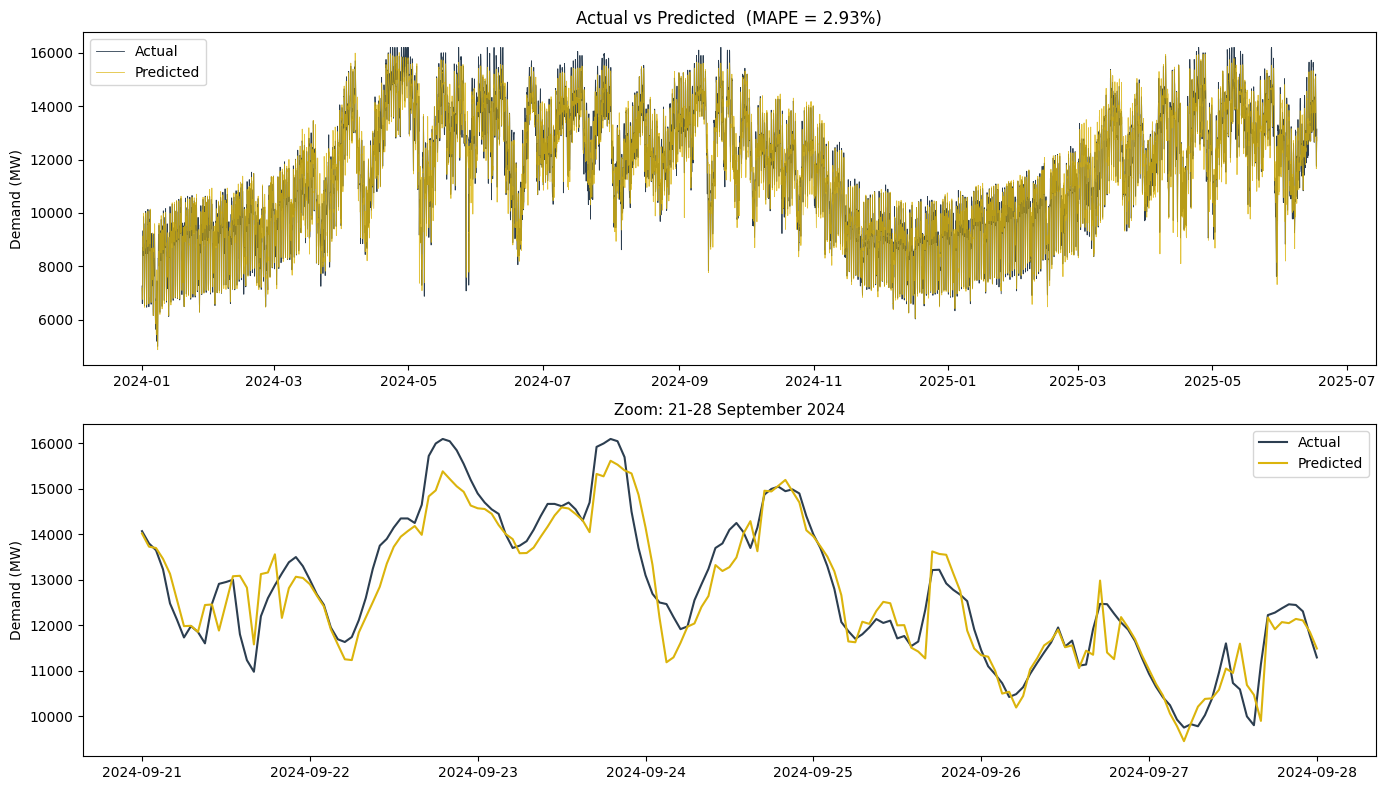

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(test.index, y_test.values, color='#2c3e50', lw=0.6, label='Actual')
axes[0].plot(test.index, predictions,   color='#DBB40C', lw=0.6, alpha=0.8, label='Predicted')
axes[0].set_title(f'Actual vs Predicted  (MAPE = {score:.2f}%)', fontsize=12)
axes[0].set_ylabel('Demand (MW)')
axes[0].legend()

zoom = (test.index >= '2024-09-21') & (test.index <= '2024-09-28')
axes[1].plot(test.index[zoom], y_test.values[zoom], color='#2c3e50', lw=1.5, label='Actual')
axes[1].plot(test.index[zoom], predictions[zoom],   color='#DBB40C', lw=1.5, label='Predicted')
axes[1].set_title('Zoom: 21-28 September 2024', fontsize=11)
axes[1].set_ylabel('Demand (MW)')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Step 8 — Feature Importance

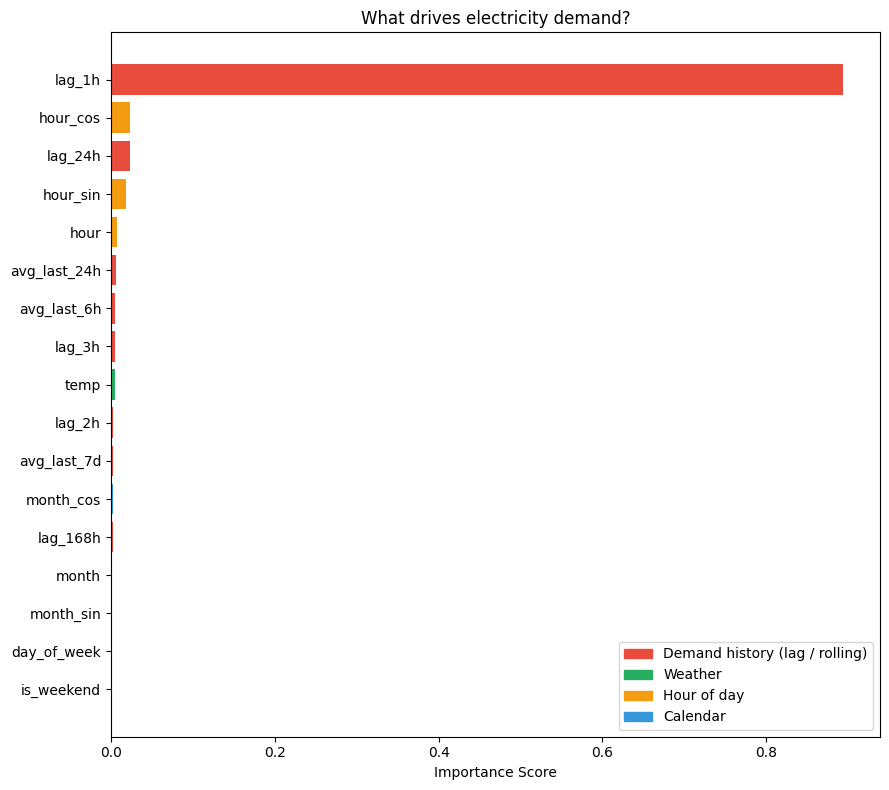

Top 5 features:
lag_1h      0.894000
hour_cos    0.023109
lag_24h     0.023100
hour_sin    0.018301
hour        0.007605


In [13]:
from matplotlib.patches import Patch

importances = pd.Series(
    model.feature_importances_,
    index = FEATURES
).sort_values(ascending=True)

colors = []
for f in importances.index:
    if 'lag' in f or 'avg' in f:
        colors.append('#e74c3c')
    elif f in 'temp':
        colors.append('#27ae60')
    elif 'hour' in f:
        colors.append('#f39c12')
    else:
        colors.append('#3498db')

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(importances.index, importances.values, color=colors)
ax.set_title('What drives electricity demand?', fontsize=12)
ax.set_xlabel('Importance Score')
ax.legend(handles=[
    Patch(color='#e74c3c', label='Demand history (lag / rolling)'),
    Patch(color='#27ae60', label='Weather'),
    Patch(color='#f39c12', label='Hour of day'),
    Patch(color='#3498db', label='Calendar'),
], loc='lower right')
plt.tight_layout()
plt.show()

print('Top 5 features:')
print(importances.sort_values(ascending=False).head(5).to_string())